# Newton'S Method

In [1]:
%matplotlib inline

In [28]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np

In [29]:
def divided_diff(x, y):
    """
    function to calculate the divided
    difference table
    """
    n = len(y)
    coef = np.zeros([n,n])
    # the first column is y
    coef[:,0] = y
    
    for j in range(1,n):
        for i in range(n-j):
            coef[i][j] = \
            (coef[i+1][j-1] - coef[i][j-1])/(x[i+j]-x[i])
            
    return coef

In [30]:
def newton_ploy(coef, x_data, x):
    """
    evaluate the newton polynomial
    at x
    """
    n = len(x_data) -1
    p = coef[n]
    for k in range(1,n+1):
        p = coef[n-k] + (x-x_data[n-k])*p
    return p

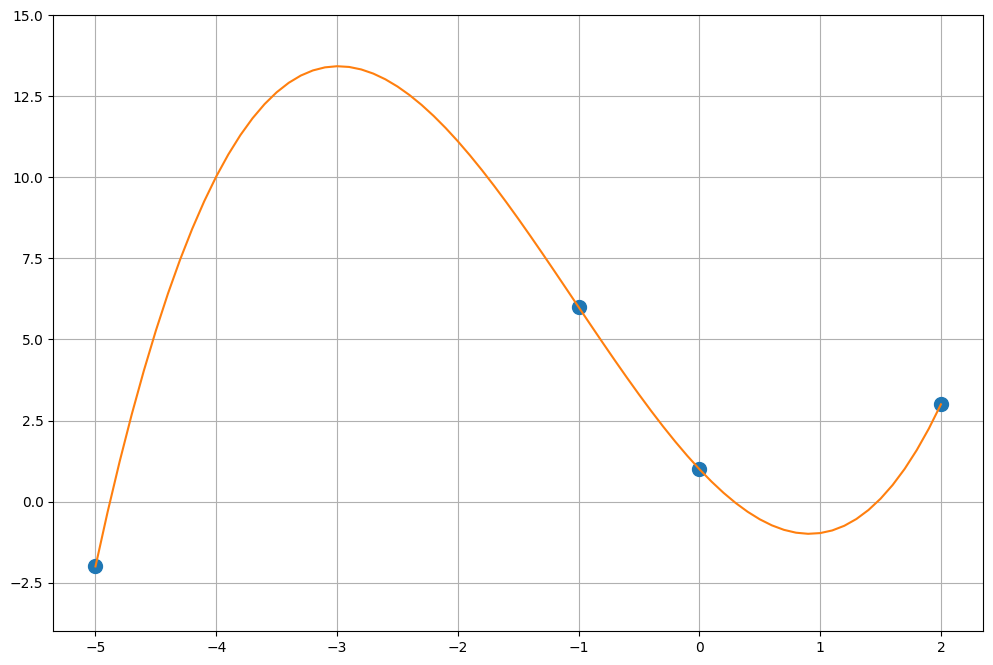

In [31]:
x = np.array([-5,-1,0,2])
y = np.array([-2,6,1,3])
# get the divided difference table
a_s = divided_diff(x,y)[0,:]

# evaluate on new data points
x_new = np.arange(-5,2.1,.1)
y_new = newton_ploy(a_s, x, x_new)

plt.figure(figsize=(12,8))
plt.plot(x,y,'o',markersize=10)
plt.plot(x_new,y_new)
plt.grid()
_ = plt.ylim((-4,15))

In [32]:
from scipy.interpolate import CubicSpline

In [33]:
x = np.array([-5,-1,0,2])
y = np.array([-2,6,1,3])

x_new = np.arange(-5,2.1,.1)

a_s = divided_diff(x,y)[0,:]
y_new = newton_ploy(a_s, x, x_new)

cub = CubicSpline(x, y, bc_type='natural')
y_cub = cub(x_new)

In [34]:
x_test = -3
y_t_n = newton_ploy(a_s, x, x_test)
y_t_c = cub(x_test)
print("Newton's interpet: ", y_t_n)
print("Cubic Spline", y_t_c)

Newton's interpet:  13.428571428571427
Cubic Spline 6.881355932203391


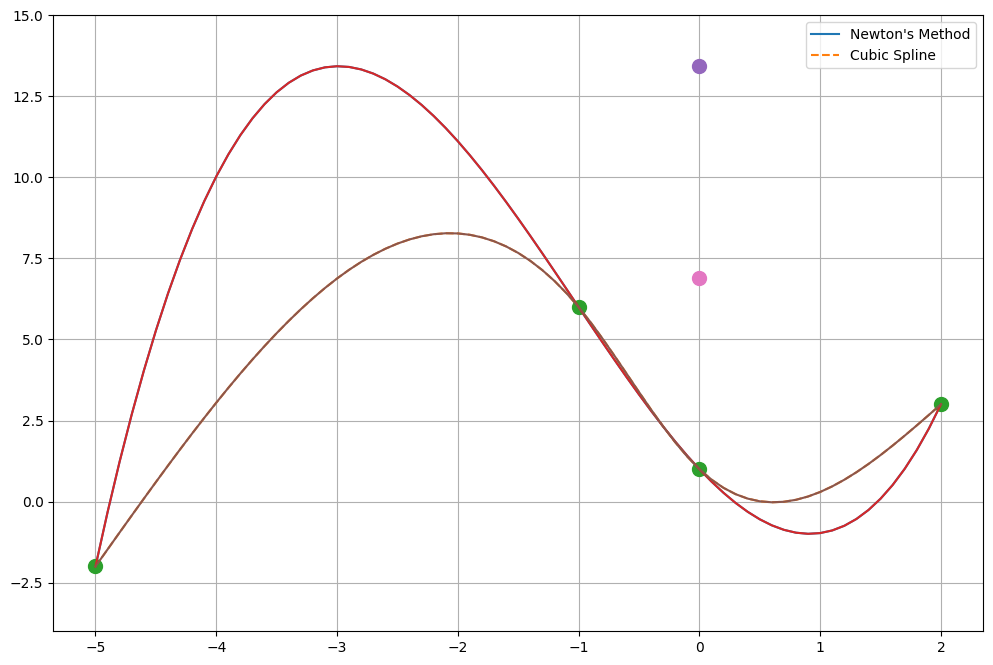

In [35]:
# evaluate on the new data
plt.figure(figsize=(12,8))
plt.plot(x_new,y_new)
plt.plot(x_new,y_cub,'--')

plt.plot(x,y,'o', markersize=10)

plt.plot(x_new,y_new, y_t_n,'o', markersize=10)
plt.plot(x_new,y_cub, y_t_c,'o', markersize=10)

plt.ylim((-4, 15))
plt.grid()
_ = plt.legend(["Newton's Method", "Cubic Spline"])